<a href="https://colab.research.google.com/github/kdnicho1-coder/2020_and_2024_Election_Results_Compared_With_US_Inequality_Atlas/blob/main/2020_and_2024_Elections_and_County_Inequality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pandas.dq
import numpy
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [4]:
import pandas as pd

# URL of the CSV file
csv_url = 'https://raw.githubusercontent.com/tonmcg/US_County_Level_Election_Results_08-24/refs/heads/master/2020_US_County_Level_Presidential_Results.csv'

# Load the CSV data into a pandas DataFrame
df = pd.read_csv(csv_url)

# Display the first 5 rows of the DataFrame
display(df.head())

,state_name,county_fips,county_name,votes_gop,votes_dem,total_votes,diff,per_gop,per_dem,per_point_diff
0,Alabama,1001,Autauga County,19838,7503,27770,12335,0.714368,0.270184,0.444184
1,Alabama,1003,Baldwin County,83544,24578,109679,58966,0.761714,0.224090,0.537623
2,Alabama,1005,Barbour County,5622,4816,10518,806,0.534512,0.457882,0.076631
3,Alabama,1007,Bibb County,7525,1986,9595,5539,0.784263,0.206983,0.577280
4,Alabama,1009,Blount County,24711,2640,27588,22071,0.895716,0.095694,0.800022


In [5]:
import pandas as pd

# URL of the CSV file
csv_url = 'https://raw.githubusercontent.com/tonmcg/US_County_Level_Election_Results_08-24/refs/heads/master/2024_US_County_Level_Presidential_Results.csv'

# Load the CSV data into a pandas DataFrame
df = pd.read_csv(csv_url)

# Display the first 5 rows of the DataFrame
display(df.head())

,state_name,county_fips,county_name,votes_gop,votes_dem,total_votes,diff,per_gop,per_dem,per_point_diff
0,Alabama,1001,Autauga County,20484,7439,28190,13045.0,0.726641,0.263888,0.462753
1,Alabama,1003,Baldwin County,95798,24934,121808,70864.0,0.786467,0.204699,0.581768
2,Alabama,1005,Barbour County,5606,4158,9832,1448.0,0.570179,0.422905,0.147274
3,Alabama,1007,Bibb County,7572,1619,9241,5953.0,0.819392,0.175197,0.644194
4,Alabama,1009,Blount County,25354,2576,28115,22778.0,0.901796,0.091624,0.810173


In [6]:
# Check for missing values in each column
missing_values = df.isnull().sum()

# Display the count of missing values
print("Missing values per column:")
display(missing_values)

# Optionally, display the total number of missing values in the DataFrame
total_missing = df.isnull().sum().sum()
print(f"\nTotal missing values in the DataFrame: {total_missing}")

Missing values per column:


,0
state_name,0
county_fips,0
county_name,0
votes_gop,0
votes_dem,0
total_votes,0
diff,0
per_gop,0
per_dem,0
per_point_diff,0



Total missing values in the DataFrame: 0


In [8]:
URL_2020 = 'https://raw.githubusercontent.com/tonmcg/US_County_Level_Election_Results_08-24/refs/heads/master/2020_US_County_Level_Presidential_Results.csv'
URL_2024 = 'https://raw.githubusercontent.com/tonmcg/US_County_Level_Election_Results_08-24/refs/heads/master/2024_US_County_Level_Presidential_Results.csv'

def normalize_fips(x):
    s = str(x).strip()
    s = "".join(ch for ch in s if ch.isdigit())
    return s.zfill(5)

def load_and_clean(url, year):
    df = pd.read_csv(url, dtype={"county_fips": str})

    # Standardize FIPS
    df["fips"] = df["county_fips"].apply(normalize_fips)

    # Ensure numeric
    numeric_cols = ["votes_gop", "votes_dem", "total_votes"]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Two-party calculations
    df["two_party_total"] = df["votes_gop"] + df["votes_dem"]
    df["gop_share_2p"] = df["votes_gop"] / df["two_party_total"]
    df["dem_share_2p"] = df["votes_dem"] / df["two_party_total"]
    df["margin_gop_points"] = df["gop_share_2p"] - df["dem_share_2p"]

    df["year"] = year

    return df[
        [
            "state_name",
            "county_name",
            "fips",
            "votes_gop",
            "votes_dem",
            "total_votes",
            "two_party_total",
            "gop_share_2p",
            "dem_share_2p",
            "margin_gop_points",
            "year",
        ]
    ]

# ----------------------------
# Load both years
# ----------------------------

df_2020 = load_and_clean(URL_2020, 2020)
df_2024 = load_and_clean(URL_2024, 2024)

# Combine into panel dataset
df_all = pd.concat([df_2020, df_2024], ignore_index=True)

# ----------------------------
# County-Level Swing
# ----------------------------

df_wide = df_all.pivot_table(
    index=["fips", "state_name", "county_name"],
    columns="year",
    values=["gop_share_2p", "margin_gop_points"],
).reset_index()

# Flatten column names
df_wide.columns = [
    "_".join(str(c) for c in col if c != "") if isinstance(col, tuple) else col
    for col in df_wide.columns
]

# Compute swing (positive = GOP shift)
df_wide["gop_swing_20_24"] = (
    df_wide["gop_share_2p_2024"] - df_wide["gop_share_2p_2020"]
)

# ----------------------------
# Summary Statistics
# ----------------------------

print("\n=== County Swing Summary ===")
print(df_wide["gop_swing_20_24"].describe())

print("\nMean GOP swing:", df_wide["gop_swing_20_24"].mean())
print("Median GOP swing:", df_wide["gop_swing_20_24"].median())

# ----------------------------
# Top Swing Counties
# ----------------------------

top_gop_shift = df_wide.sort_values("gop_swing_20_24", ascending=False).head(15)
top_dem_shift = df_wide.sort_values("gop_swing_20_24", ascending=True).head(15)

print("\n=== Largest GOP Shifts ===")
print(top_gop_shift[["state_name", "county_name", "gop_swing_20_24"]])

print("\n=== Largest DEM Shifts ===")
print(top_dem_shift[["state_name", "county_name", "gop_swing_20_24"]])

# ----------------------------
# State-Level Aggregation
# ----------------------------

state = (
    df_all.groupby(["state_name", "year"], as_index=False)
    .agg(
        votes_gop=("votes_gop", "sum"),
        votes_dem=("votes_dem", "sum"),
        total_votes=("total_votes", "sum"),
    )
)

state["two_party_total"] = state["votes_gop"] + state["votes_dem"]
state["gop_share_2p"] = state["votes_gop"] / state["two_party_total"]

state_wide = state.pivot(index="state_name", columns="year", values="gop_share_2p").reset_index()
state_wide.columns = ["state_name", "gop_2020", "gop_2024"]

state_wide["gop_swing_20_24"] = state_wide["gop_2024"] - state_wide["gop_2020"]

print("\n=== State-Level Swing ===")
print(state_wide.sort_values("gop_swing_20_24", ascending=False).head(10))

# ----------------------------
# Save outputs
# ----------------------------

df_all.to_csv("county_panel_2020_2024.csv", index=False)
df_wide.to_csv("county_swing_2020_2024.csv", index=False)
state_wide.to_csv("state_swing_2020_2024.csv", index=False)

print("\nFiles saved:")
print(" - county_panel_2020_2024.csv")
print(" - county_swing_2020_2024.csv")
print(" - state_swing_2020_2024.csv")


=== County Swing Summary ===
count    3103.000000
mean        0.017049
std         0.016710
min        -0.045756
25%         0.006737
50%         0.015337
75%         0.025301
max         0.140677
Name: gop_swing_20_24, dtype: float64

Mean GOP swing: 0.017048771838075842
Median GOP swing: 0.015337221241271237

=== Largest GOP Shifts ===
      state_name        county_name  gop_swing_20_24
2751       Texas    Maverick County         0.140677
249   California    Imperial County         0.128946
2829       Texas        Webb County         0.128520
1897    New York       Bronx County         0.112725
2803       Texas       Starr County         0.105496
1935    New York      Queens County         0.104958
2653       Texas      Dimmit County         0.104230
2660       Texas     El Paso County         0.102095
2697       Texas     Hidalgo County         0.100617
2644       Texas   Culberson County         0.099196
1856  New Jersey     Passaic County         0.098652
2620       Texas     Ca

In [9]:
print("Unique counties 2020:", df_2020["fips"].nunique())
print("Unique counties 2024:", df_2024["fips"].nunique())

Unique counties 2020: 3152
Unique counties 2024: 3160


Running Diagnostic I got from ChatGPT


In [10]:
set_2020 = set(df_2020["fips"])
set_2024 = set(df_2024["fips"])

only_2020 = set_2020 - set_2024
only_2024 = set_2024 - set_2020
both = set_2020 & set_2024

print("Only in 2020:", len(only_2020))
print("Only in 2024:", len(only_2024))
print("In both:", len(both))

print("\nExample only in 2020:", list(only_2020)[:10])
print("Example only in 2024:", list(only_2024)[:10])

Only in 2020: 48
Only in 2024: 56
In both: 3104

Example only in 2020: ['02910', '02918', '02919', '02923', '09007', '02905', '02904', '02920', '02930', '02902']
Example only in 2024: ['02029', '11004', '02031', '02022', '02035', '02007', '02015', '02010', '09190', '02017']


There are inconsistancies in Alaska, Connecticut, and Washington DC, so dropping those.

In [15]:
exclude_states = ["Alaska", "District of Columbia", "Connecticut"]

df_2020_clean = df_2020[~df_2020["state_name"].isin(exclude_states)]
df_2024_clean = df_2024[~df_2024["state_name"].isin(exclude_states)]

In [19]:
(df_wide["state_name"].unique())

array(['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California',
       'Colorado', 'Connecticut', 'Delaware', 'District of Columbia',
       'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana',
       'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland',
       'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi',
       'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire',
       'New Jersey', 'New Mexico', 'New York', 'North Carolina',
       'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
       'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee',
       'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington',
       'West Virginia', 'Wisconsin', 'Wyoming'], dtype=object)

Okay that didn't work trying something else.

In [20]:
exclude_states = ["Alaska", "District of Columbia", "Connecticut"]

# Filter BOTH years
df_2020_clean = df_2020[~df_2020["state_name"].isin(exclude_states)].copy()
df_2024_clean = df_2024[~df_2024["state_name"].isin(exclude_states)].copy()

# Recombine
df_all_clean = pd.concat([df_2020_clean, df_2024_clean], ignore_index=True)

# Rebuild pivot
df_wide_clean = df_all_clean.pivot_table(
    index=["fips", "state_name", "county_name"],
    columns="year",
    values=["gop_share_2p"],
).reset_index()

df_wide_clean.columns = [
    "_".join(str(c) for c in col if c != "") if isinstance(col, tuple) else col
    for col in df_wide_clean.columns
]

df_wide_clean["gop_swing_20_24"] = (
    df_wide_clean["gop_share_2p_2024"] -
    df_wide_clean["gop_share_2p_2020"]
)

In [21]:
(df_wide["state_name"].unique())

array(['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California',
       'Colorado', 'Connecticut', 'Delaware', 'District of Columbia',
       'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana',
       'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland',
       'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi',
       'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire',
       'New Jersey', 'New Mexico', 'New York', 'North Carolina',
       'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
       'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee',
       'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington',
       'West Virginia', 'Wisconsin', 'Wyoming'], dtype=object)

In [22]:
exclude_states = ["Alaska", "District of Columbia", "Connecticut"]

# 1. Filter both years
df_2020 = df_2020[~df_2020["state_name"].isin(exclude_states)].copy()
df_2024 = df_2024[~df_2024["state_name"].isin(exclude_states)].copy()

# 2. Recombine
df_all = pd.concat([df_2020, df_2024], ignore_index=True)

# 3. Rebuild pivot
df_wide = df_all.pivot_table(
    index=["fips", "state_name", "county_name"],
    columns="year",
    values="gop_share_2p"
).reset_index()

# Flatten column names
df_wide.columns = ["fips", "state_name", "county_name",
                   "gop_2020", "gop_2024"]

# 4. Compute swing
df_wide["gop_swing_20_24"] = df_wide["gop_2024"] - df_wide["gop_2020"]

In [23]:
print(sorted(df_wide["state_name"].unique()))

['Alabama', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']


In [24]:
print("Counties in both years after drop:", len(df_wide))
print("Missing any 2020 shares?", df_wide["gop_2020"].isna().sum())
print("Missing any 2024 shares?", df_wide["gop_2024"].isna().sum())

Counties in both years after drop: 3103
Missing any 2020 shares? 0
Missing any 2024 shares? 0


In [25]:
print(df_wide[df_wide["fips"].str[:2].isin(["02","09","11"])].shape[0])

0


Now that the data matches we can go back to analyzing.


In [26]:
df_change = df_2020.merge(
    df_2024,
    on=["fips", "state_name", "county_name"],
    suffixes=("_2020", "_2024")
)

# Raw vote change
df_change["gop_vote_change"] = (
    df_change["votes_gop_2024"] - df_change["votes_gop_2020"]
)

df_change["dem_vote_change"] = (
    df_change["votes_dem_2024"] - df_change["votes_dem_2020"]
)

df_change["turnout_change"] = (
    df_change["total_votes_2024"] - df_change["total_votes_2020"]
)

# Share change (already computed before, but recompute cleanly)
df_change["gop_share_2020"] = (
    df_change["votes_gop_2020"] /
    (df_change["votes_gop_2020"] + df_change["votes_dem_2020"])
)

df_change["gop_share_2024"] = (
    df_change["votes_gop_2024"] /
    (df_change["votes_gop_2024"] + df_change["votes_dem_2024"])
)

df_change["gop_swing"] = (
    df_change["gop_share_2024"] - df_change["gop_share_2020"]
)

In [27]:
df_change["winner_2020"] = (
    df_change["votes_gop_2020"] >
    df_change["votes_dem_2020"]
)

df_change["winner_2024"] = (
    df_change["votes_gop_2024"] >
    df_change["votes_dem_2024"]
)

df_change["flipped"] = (
    df_change["winner_2020"] !=
    df_change["winner_2024"]
)

print("Counties that flipped:", df_change["flipped"].sum())

Counties that flipped: 86


In [28]:
# Count flips by direction
flips = df_change[df_change["flipped"]]

to_gop = flips[(flips["winner_2020"] == False) & (flips["winner_2024"] == True)].shape[0]
to_dem = flips[(flips["winner_2020"] == True) & (flips["winner_2024"] == False)].shape[0]

print("Flipped from Dem to GOP:", to_gop)
print("Flipped from GOP to Dem:", to_dem)

Flipped from Dem to GOP: 86
Flipped from GOP to Dem: 0


In [30]:
# Create raw vote margins
df_change["margin_2020"] = (
    df_change["votes_gop_2020"] -
    df_change["votes_dem_2020"]
)

df_change["margin_2024"] = (
    df_change["votes_gop_2024"] -
    df_change["votes_dem_2024"]
)

# Now re-create flips subset (important)
flips = df_change[df_change["flipped"]].copy()

In [31]:
flips = df_change[df_change["flipped"]]

print("2020 margin (absolute) summary:")
print(flips["margin_2020"].abs().describe())

print("\n2024 margin summary:")
print(flips["margin_2024"].describe())

2020 margin (absolute) summary:
count       86.000000
mean      8929.534884
std      19291.117608
min         14.000000
25%        248.750000
50%        820.000000
75%       4171.000000
max      89602.000000
Name: margin_2020, dtype: float64

2024 margin summary:
count        86.000000
mean       6138.174419
std       16569.640762
min           6.000000
25%         267.000000
50%         955.500000
75%        3894.750000
max      125235.000000
Name: margin_2024, dtype: float64


In [32]:
flips.loc[flips["margin_2020"].abs().idxmax(),
          ["state_name", "county_name", "margin_2020", "gop_swing"]]

,192
state_name,California
county_name,San Bernardino County
margin_2020,-89602
gop_swing,0.065502


In [35]:
flips = flips.copy()
flips.loc[:, "close_2020"] = flips["margin_2020"].abs() < 5000

print("Close in 2020:", flips["close_2020"].sum())
print("Not close in 2020:", (~flips["close_2020"]).sum())

Close in 2020: 65
Not close in 2020: 21


In [34]:
structural_flips = flips[flips["margin_2020"].abs() > 5000].copy()

structural_flips["gop_vote_change"] = (
    structural_flips["votes_gop_2024"] -
    structural_flips["votes_gop_2020"]
)

structural_flips["dem_vote_change"] = (
    structural_flips["votes_dem_2024"] -
    structural_flips["votes_dem_2020"]
)

structural_flips[[
    "state_name",
    "county_name",
    "margin_2020",
    "gop_vote_change",
    "dem_vote_change",
    "gop_swing"
]]

,state_name,county_name,margin_2020,gop_vote_change,dem_vote_change,gop_swing
74,Arizona,Maricopa County,-45109,55866,-60758,0.028677
166,California,Fresno County,-28561,1460,-41397,0.062456
169,California,Imperial County,-13831,5699,-8595,0.128946
180,California,Merced County,-9594,4558,-8801,0.076644
189,California,Riverside County,-79243,14975,-76163,0.047066
192,California,San Bernardino County,-89602,12159,-93745,0.065502
195,California,San Joaquin County,-40039,7898,-34490,0.075526
296,Florida,Duval County,-18794,2523,-23191,0.026753
309,Florida,Hillsborough County,-48969,14619,-54912,0.050286
324,Florida,Miami-Dade County,-85031,72757,-137509,0.094609


In [36]:
# Turnout change % (relative)
df_change["turnout_pct_change"] = (
    (df_change["total_votes_2024"] - df_change["total_votes_2020"])
    / df_change["total_votes_2020"]
)

# Party vote change as % of 2020 total turnout
df_change["gop_vote_change_pct_of_2020_turnout"] = (
    (df_change["votes_gop_2024"] - df_change["votes_gop_2020"])
    / df_change["total_votes_2020"]
)

df_change["dem_vote_change_pct_of_2020_turnout"] = (
    (df_change["votes_dem_2024"] - df_change["votes_dem_2020"])
    / df_change["total_votes_2020"]
)

flips_struct = df_change[df_change["flipped"] & (df_change["margin_2020"].abs() > 5000)].copy()

flips_struct[[
    "state_name","county_name",
    "turnout_pct_change",
    "gop_vote_change_pct_of_2020_turnout",
    "dem_vote_change_pct_of_2020_turnout",
    "gop_swing"
]].sort_values("gop_swing", ascending=False)

,state_name,county_name,turnout_pct_change,gop_vote_change_pct_of_2020_turnout,dem_vote_change_pct_of_2020_turnout,gop_swing
169,California,Imperial County,-0.047481,0.100480,-0.151539,0.128946
2723,Texas,Webb County,-0.037312,0.109449,-0.144275,0.128520
2591,Texas,Hidalgo County,-0.016706,0.091600,-0.107215,0.100617
1750,New Jersey,Passaic County,-0.096122,0.039874,-0.151299,0.098652
2514,Texas,Cameron County,0.017062,0.104744,-0.085878,0.095664
324,Florida,Miami-Dade County,-0.054220,0.062894,-0.118869,0.094609
330,Florida,Osceola County,0.001972,0.076742,-0.075924,0.077068
180,California,Merced County,-0.045825,0.050342,-0.097205,0.076644
195,California,San Joaquin County,-0.085882,0.027381,-0.119573,0.075526
1818,New York,Nassau County,-0.035776,0.056500,-0.079262,0.069261


Validating

In [37]:
# Check total votes consistency
check_2020 = (
    df_change["votes_gop_2020"] +
    df_change["votes_dem_2020"]
)

check_2024 = (
    df_change["votes_gop_2024"] +
    df_change["votes_dem_2024"]
)

print("2020 mismatch:",
      (check_2020 != df_change["total_votes_2020"]).sum())

print("2024 mismatch:",
      (check_2024 != df_change["total_votes_2024"]).sum())

2020 mismatch: 3101
2024 mismatch: 3036


In [38]:
# recompute shares from scratch
re_gop_2020 = df_change["votes_gop_2020"] / (
    df_change["votes_gop_2020"] + df_change["votes_dem_2020"]
)

re_gop_2024 = df_change["votes_gop_2024"] / (
    df_change["votes_gop_2024"] + df_change["votes_dem_2024"]
)

re_swing = re_gop_2024 - re_gop_2020

print("Max swing diff:",
      (re_swing - df_change["gop_swing"]).abs().max())

Max swing diff: 0.0


In [39]:
print("Duplicate FIPS rows:",
      df_change.duplicated("fips").sum())

Duplicate FIPS rows: 0


In [40]:
print("Counties:", len(df_change))

Counties: 3103


In [41]:
national = df_change[[
    "votes_gop_2020", "votes_dem_2020",
    "votes_gop_2024", "votes_dem_2024"
]].sum()

print(national)

votes_gop_2020    73284427
votes_dem_2020    79713586
votes_gop_2024    76352398
votes_dem_2024    73580811
dtype: int64


In [42]:
gop_share_2020_nat = national["votes_gop_2020"] / (
    national["votes_gop_2020"] + national["votes_dem_2020"]
)

gop_share_2024_nat = national["votes_gop_2024"] / (
    national["votes_gop_2024"] + national["votes_dem_2024"]
)

print("National GOP share 2020:", gop_share_2020_nat)
print("National GOP share 2024:", gop_share_2024_nat)
print("National swing:", gop_share_2024_nat - gop_share_2020_nat)

National GOP share 2020: 0.47898940360748343
National GOP share 2024: 0.5092427388784829
National swing: 0.030253335270999493


In [43]:
df_change.sort_values("gop_vote_change", ascending=False).head(10)

,state_name,county_name,fips,votes_gop_2020,votes_dem_2020,total_votes_2020,two_party_total_2020,gop_share_2p_2020,dem_share_2p_2020,margin_gop_points_2020,...,gop_share_2024,gop_swing,winner_2020,winner_2024,flipped,margin_2020,margin_2024,turnout_pct_change,gop_vote_change_pct_of_2020_turnout,dem_vote_change_pct_of_2020_turnout
324,Florida,Miami-Dade County,12086,532833,617864,1156816,1150697,0.463052,0.536948,-0.073895,...,0.557662,0.094609,False,True,True,-85031,125235,-0.054220,0.062894,-0.118869
1709,Nevada,Clark County,32003,430930,521852,972510,952782,0.452286,0.547714,-0.095428,...,0.486610,0.034324,False,False,False,-90922,-27135,0.060373,0.063878,-0.001712
74,Arizona,Maricopa County,04013,995665,1040774,2069475,2036439,0.488925,0.511075,-0.022151,...,0.517601,0.028677,False,True,True,-45109,71515,-0.007504,0.026995,-0.029359
1829,New York,Queens County,36081,212665,569038,787860,781703,0.272053,0.727947,-0.455893,...,0.377011,0.104958,False,False,False,-356373,-172654,-0.109093,0.065955,-0.167233
175,California,Los Angeles County,06037,1145530,3028885,4263443,4174415,0.274417,0.725583,-0.451166,...,0.329878,0.055462,False,False,False,-1883355,-1227247,-0.125489,0.010398,-0.143493
1818,New York,Nassau County,36059,326716,396504,732756,723220,0.451752,0.548248,-0.096496,...,0.521013,0.069261,False,True,True,-69788,29693,-0.035776,0.056500,-0.079262
1840,New York,Suffolk County,36103,381253,381021,771541,762274,0.500152,0.499848,0.000304,...,0.549869,0.049717,True,True,False,232,75737,-0.015787,0.047044,-0.050819
331,Florida,Palm Beach County,12099,334711,433572,773158,768283,0.435661,0.564339,-0.128678,...,0.496161,0.060500,False,False,False,-98861,-5676,-0.035518,0.041550,-0.078975
1812,New York,Kings County,36047,202772,703310,913246,906082,0.223790,0.776210,-0.552420,...,0.280120,0.056330,False,False,False,-500538,-367301,-0.085428,0.034155,-0.111739
1791,New York,Bronx County,36005,67740,355374,425715,423114,0.160099,0.839901,-0.679803,...,0.272824,0.112725,False,False,False,-287634,-163496,-0.154730,0.071489,-0.220110


In [44]:
test = df_change[df_change["flipped"]][
    ["county_name",
     "votes_gop_2020","votes_dem_2020",
     "votes_gop_2024","votes_dem_2024"]
]

print(test.head())

         county_name  votes_gop_2020  votes_dem_2020  votes_gop_2024  \
45    Marengo County            5343            5488            4995   
74   Maricopa County          995665         1040774         1051531   
102     Desha County            1921            2016            1805   
160     Butte County           48730           50426           47179   
166    Fresno County          164464          193025          165924   

     votes_dem_2024  
45             4631  
74           980016  
102            1638  
160           44228  
166          151628  


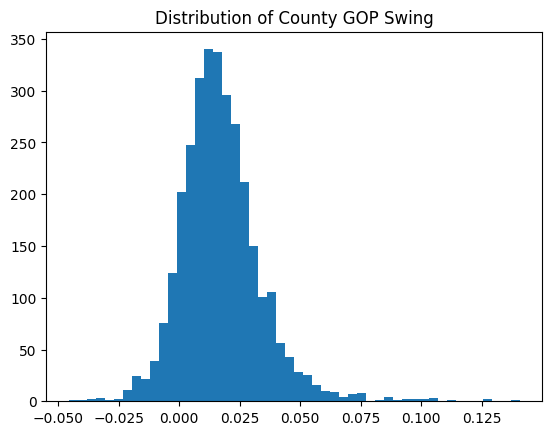

In [45]:
import matplotlib.pyplot as plt

plt.hist(df_change["gop_swing"], bins=50)
plt.title("Distribution of County GOP Swing")
plt.show()

In [46]:
state = df_change.groupby("state_name")[[
    "votes_gop_2020","votes_dem_2020",
    "votes_gop_2024","votes_dem_2024"
]].sum()

state["gop_share_2020"] = state["votes_gop_2020"] / (
    state["votes_gop_2020"] + state["votes_dem_2020"]
)

state["gop_share_2024"] = state["votes_gop_2024"] / (
    state["votes_gop_2024"] + state["votes_dem_2024"]
)

print(state.sort_values("gop_share_2024", ascending=False).head(10))

               votes_gop_2020  votes_dem_2020  votes_gop_2024  votes_dem_2024  \
state_name                                                                      
Wyoming                193559           73491          192633           69527   
West Virginia          545382          235984          533556          214309   
Idaho                  554118          287021          605246          274972   
North Dakota           235595          114902          246505          112327   
Oklahoma              1020280          503890         1036213          499599   
Arkansas               760647          423932          759241          396905   
Kentucky              1326646          772474         1337494          704043   
Alabama               1441168          849648         1462616          772412   
Tennessee             1852475         1143711         1966865         1056265   
South Dakota           261043          150471          272081          146859   

               gop_share_20

In [47]:
state = df_change.groupby("state_name")[[
    "votes_gop_2020","votes_dem_2020",
    "votes_gop_2024","votes_dem_2024"
]].sum()

state["gop_share_2020"] = state["votes_gop_2020"] / (
    state["votes_gop_2020"] + state["votes_dem_2020"]
)

state["gop_share_2024"] = state["votes_gop_2024"] / (
    state["votes_gop_2024"] + state["votes_dem_2024"]
)

print(state.sort_values("gop_share_2024", ascending=False).head(10))

               votes_gop_2020  votes_dem_2020  votes_gop_2024  votes_dem_2024  \
state_name                                                                      
Wyoming                193559           73491          192633           69527   
West Virginia          545382          235984          533556          214309   
Idaho                  554118          287021          605246          274972   
North Dakota           235595          114902          246505          112327   
Oklahoma              1020280          503890         1036213          499599   
Arkansas               760647          423932          759241          396905   
Kentucky              1326646          772474         1337494          704043   
Alabama               1441168          849648         1462616          772412   
Tennessee             1852475         1143711         1966865         1056265   
South Dakota           261043          150471          272081          146859   

               gop_share_20

In [48]:
print(national.sum())

302931222


In [49]:
calc_margin_change = (
    (df_change["votes_gop_2024"] - df_change["votes_dem_2024"]) -
    (df_change["votes_gop_2020"] - df_change["votes_dem_2020"])
)

print("Max margin diff:",
      (calc_margin_change - (df_change["margin_2024"] - df_change["margin_2020"])).abs().max())

Max margin diff: 0


In [50]:
df_change["margin_change"] = df_change["margin_2024"] - df_change["margin_2020"]

direction_mismatch = (
    (df_change["gop_swing"] > 0) &
    (df_change["margin_change"] <= 0)
).sum()

print("Directional mismatches:", direction_mismatch)

Directional mismatches: 253


In [51]:
weird = df_change[
    (df_change["turnout_pct_change"] < 0) &
    (df_change["gop_vote_change"] > 0) &
    (df_change["dem_vote_change"] > 0)
]

print("Impossible turnout cases:", len(weird))

Impossible turnout cases: 7


In [52]:
inconsistent = df_change[
    (df_change["gop_vote_change"] - df_change["dem_vote_change"] > 0) &
    (df_change["gop_swing"] <= 0)
]

print("Vote/share inconsistency cases:", len(inconsistent))

Vote/share inconsistency cases: 112


In [53]:
weights = df_change["total_votes_2020"]

weighted_swing = np.average(
    df_change["gop_swing"],
    weights=weights
)

print("Unweighted swing:", df_change["gop_swing"].mean())
print("Vote-weighted swing:", weighted_swing)

NameError: name 'np' is not defined

In [54]:
flips = df_change[df_change["flipped"]]

print("Median turnout (all counties):",
      df_change["total_votes_2020"].median())

print("Median turnout (flips):",
      flips["total_votes_2020"].median())

Median turnout (all counties): 12495.0
Median turnout (flips): 35744.0


In [57]:
# Method A
state = df_change.groupby("state_name").agg({
    "votes_gop_2020":"sum",
    "votes_dem_2020":"sum",
    "votes_gop_2024":"sum",
    "votes_dem_2024":"sum"
})

state["swing_A"] = (
    (state["votes_gop_2024"] / (state["votes_gop_2024"] + state["votes_dem_2024"])) -
    (state["votes_gop_2020"] / (state["votes_gop_2020"] + state["votes_dem_2020"]))
)



In [61]:
import numpy as np

In [62]:

# Method B
state_B = (
    df_change.groupby("state_name")
    .apply(lambda x: np.average(x["gop_swing"],
                                weights=x["total_votes_2020"]))
)

print((state["swing_A"] - state_B).abs().max())

0.009996735818315942


/tmp/ipykernel_356/1793074145.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: np.average(x["gop_swing"],


In [63]:
weights = df_change["total_votes_2020"]

weighted_swing = np.average(
    df_change["gop_swing"],
    weights=weights
)

print("Unweighted swing:", df_change["gop_swing"].mean())
print("Vote-weighted swing:", weighted_swing)

Unweighted swing: 0.017048771838075842
Vote-weighted swing: 0.02455464329215442


In [64]:
top10 = df_change.sort_values("total_votes_2020", ascending=False).head(10)

print("Top 10 counties weighted swing contribution:")
print(np.average(top10["gop_swing"], weights=top10["total_votes_2020"]))

Top 10 counties weighted swing contribution:
0.04231653411090578


In [65]:
state_A = df_change.groupby("state_name").agg({
    "votes_gop_2020":"sum",
    "votes_dem_2020":"sum",
    "votes_gop_2024":"sum",
    "votes_dem_2024":"sum"
})

state_A["swing_A"] = (
    (state_A["votes_gop_2024"] /
     (state_A["votes_gop_2024"] + state_A["votes_dem_2024"])) -
    (state_A["votes_gop_2020"] /
     (state_A["votes_gop_2020"] + state_A["votes_dem_2020"]))
)

state_B = (
    df_change.groupby("state_name")
    .apply(lambda x: np.average(
        x["gop_swing"],
        weights=x["total_votes_2020"]
    ))
)

print("Max difference between methods:",
      (state_A["swing_A"] - state_B).abs().max())

Max difference between methods: 0.009996735818315942


/tmp/ipykernel_356/3928555367.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: np.average(


In [66]:
top10 = df_change.sort_values("total_votes_2020", ascending=False).head(10)

national_without_top10 = np.average(
    df_change[~df_change["fips"].isin(top10["fips"])]["gop_swing"],
    weights=df_change[~df_change["fips"].isin(top10["fips"])]["total_votes_2020"]
)

print("National swing overall:", weighted_swing)
print("National swing without top 10 counties:", national_without_top10)

National swing overall: 0.02455464329215442
National swing without top 10 counties: 0.022271432854032745


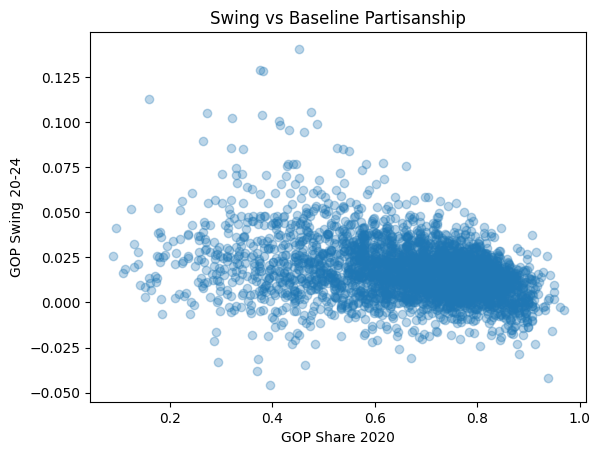

In [67]:
import matplotlib.pyplot as plt

plt.scatter(df_change["gop_share_2020"],
            df_change["gop_swing"],
            alpha=0.3)

plt.xlabel("GOP Share 2020")
plt.ylabel("GOP Swing 20-24")
plt.title("Swing vs Baseline Partisanship")
plt.show()

In [68]:
import numpy as np

correlation = np.corrcoef(
    df_change["gop_share_2020"],
    df_change["gop_swing"]
)[0,1]

print("Correlation:", correlation)

Correlation: -0.32278050703688493


In [69]:
import statsmodels.api as sm

X = sm.add_constant(df_change["gop_share_2020"])
y = df_change["gop_swing"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              gop_swing   R-squared:                       0.104
Model:                            OLS   Adj. R-squared:                  0.104
Method:                 Least Squares   F-statistic:                     360.7
Date:                Thu, 05 Mar 2026   Prob (F-statistic):           3.62e-76
Time:                        09:27:41   Log-Likelihood:                 8465.0
No. Observations:                3103   AIC:                        -1.693e+04
Df Residuals:                    3101   BIC:                        -1.691e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.0390      0.001     32.

At this point I had to accept the math wors and move on.


In [70]:
X = sm.add_constant(df_change[[
    "gop_share_2020",
    "turnout_pct_change"
]])

y = df_change["gop_swing"]

model2 = sm.OLS(y, X).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:              gop_swing   R-squared:                       0.142
Model:                            OLS   Adj. R-squared:                  0.142
Method:                 Least Squares   F-statistic:                     257.5
Date:                Thu, 05 Mar 2026   Prob (F-statistic):          3.37e-104
Time:                        09:31:24   Log-Likelihood:                 8532.8
No. Observations:                3103   AIC:                        -1.706e+04
Df Residuals:                    3100   BIC:                        -1.704e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.0356      0

In [78]:
print(df_change.columns.tolist())

['state_name', 'county_name', 'fips', 'votes_gop_2020', 'votes_dem_2020', 'total_votes_2020', 'two_party_total_2020', 'gop_share_2p_2020', 'dem_share_2p_2020', 'margin_gop_points_2020', 'year_2020', 'votes_gop_2024', 'votes_dem_2024', 'total_votes_2024', 'two_party_total_2024', 'gop_share_2p_2024', 'dem_share_2p_2024', 'margin_gop_points_2024', 'year_2024', 'gop_vote_change', 'dem_vote_change', 'turnout_change', 'gop_share_2020', 'gop_share_2024', 'gop_swing', 'winner_2020', 'winner_2024', 'flipped', 'margin_2020', 'margin_2024', 'turnout_pct_change', 'gop_vote_change_pct_of_2020_turnout', 'dem_vote_change_pct_of_2020_turnout', 'margin_change']


In [76]:
import kagglehub
path = kagglehub.dataset_download("lucassteuber/us-inequality-atlas")

100%|██████████| 1.14M/1.14M [00:00<00:00, 62.1MB/s]

Extracting files...


In [85]:
import os
print(os.listdir("."))

['.config', 'county_panel_2020_2024.csv', 'state_swing_2020_2024.csv', 'county_swing_2020_2024.csv', 'sample_data']


In [92]:
import os
print(os.listdir("lucassteuber/us-inequality-atlas"))  # confirm the uploaded filename

FileNotFoundError: [Errno 2] No such file or directory: 'lucassteuber/us-inequality-atlas'

In [91]:
import kagglehub
path = kagglehub.dataset_download("lucassteuber/us-inequality-atlas")

Using Colab cache for faster access to the 'us-inequality-atlas' dataset.


In [93]:
print(path)

/kaggle/input/us-inequality-atlas


In [94]:
import os
print(os.listdir("/kaggle/input/us-inequality-atlas"))

['DATASET_CARD.md', 'food_deserts', 'housing', 'veterans', 'README.md', 'economic', 'cms', 'healthcare', 'disability', 'education']


In [ ]:
import pandas as pd

ineq = pd.read_csv("/kaggle/input/us-inequality-atlas/ACTUAL_FILENAME.csv", dtype=str)

print(ineq.shape)
print(ineq.columns[:50])

In [95]:
import os

base = "/kaggle/input/us-inequality-atlas"

csvs = []
for root, dirs, files in os.walk(base):
    for f in files:
        if f.lower().endswith(".csv"):
            csvs.append(os.path.join(root, f))

print("CSV count:", len(csvs))
print("\n".join(csvs[:50]))  # show first 50

CSV count: 20
/kaggle/input/us-inequality-atlas/food_deserts/food_desert_merged.csv
/kaggle/input/us-inequality-atlas/housing/housing_crisis_merged.csv
/kaggle/input/us-inequality-atlas/veterans/military_firearm_merged_analysis.csv
/kaggle/input/us-inequality-atlas/veterans/military_firearm_ffl.csv
/kaggle/input/us-inequality-atlas/veterans/military_firearm_economic_impact.csv
/kaggle/input/us-inequality-atlas/veterans/military_firearm_veterans.csv
/kaggle/input/us-inequality-atlas/veterans/military_firearm_firearms.csv
/kaggle/input/us-inequality-atlas/veterans/military_firearm_spouse_employment.csv
/kaggle/input/us-inequality-atlas/veterans/military_firearm_ptsd.csv
/kaggle/input/us-inequality-atlas/veterans/military_firearm_va_healthcare.csv
/kaggle/input/us-inequality-atlas/veterans/military_firearm_suicide.csv
/kaggle/input/us-inequality-atlas/veterans/military_firearm_active_duty.csv
/kaggle/input/us-inequality-atlas/economic/unemployment_by_county.csv
/kaggle/input/us-inequality

In [97]:
import pandas as pd

gini_path = "/kaggle/input/us-inequality-atlas/economic/gini_by_county.csv"
gini = pd.read_csv(gini_path)

print(gini.shape)
print(gini.columns.tolist())
print(gini.head())

(3222, 4)
['fips', 'county_name', 'state', 'gini_index']
   fips     county_name state  gini_index
0  1001  Autauga County    AL      0.4541
1  1003  Baldwin County    AL      0.4648
2  1005  Barbour County    AL      0.5098
3  1007     Bibb County    AL      0.4553
4  1009   Blount County    AL      0.4475


We need to take Alaska and Connecticut out of this one.

In [99]:
exclude_states = ["Alaska", "Connecticut"]

df_merged = df_merged[
    ~df_merged["state_name"].isin(exclude_states)
].copy()

print("Rows after exclusion:", len(df_merged))

Rows after exclusion: 3103


In [100]:
import statsmodels.api as sm

df_merged["gini_index"] = pd.to_numeric(df_merged["gini_index"], errors="coerce")

X = sm.add_constant(
    df_merged[[
        "gop_share_2020",
        "turnout_pct_change",
        "gini_index"
    ]].dropna()
)

y = df_merged.loc[X.index, "gop_swing"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              gop_swing   R-squared:                       0.158
Model:                            OLS   Adj. R-squared:                  0.158
Method:                 Least Squares   F-statistic:                     194.4
Date:                Thu, 05 Mar 2026   Prob (F-statistic):          1.73e-115
Time:                        09:52:41   Log-Likelihood:                 8561.8
No. Observations:                3103   AIC:                        -1.712e+04
Df Residuals:                    3099   BIC:                        -1.709e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.0070      0

More unequal counties swung more Republican.


In [101]:
df_merged.to_csv("merged_election_inequality.csv", index=False)

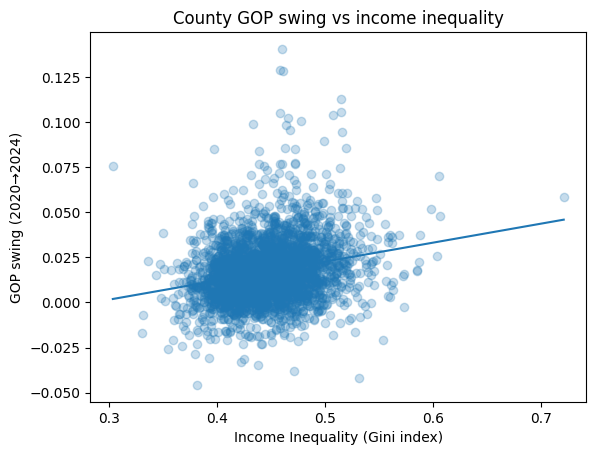

In [102]:
import numpy as np
import matplotlib.pyplot as plt

d = df_merged[["gini_index", "gop_swing"]].copy()
d["gini_index"] = pd.to_numeric(d["gini_index"], errors="coerce")
d = d.dropna()

plt.figure()
plt.scatter(d["gini_index"], d["gop_swing"], alpha=0.25)

m, b = np.polyfit(d["gini_index"], d["gop_swing"], 1)
x = np.array([d["gini_index"].min(), d["gini_index"].max()])
plt.plot(x, m*x + b)

plt.xlabel("Income Inequality (Gini index)")
plt.ylabel("GOP swing (2020→2024)")
plt.title("County GOP swing vs income inequality")
plt.show()

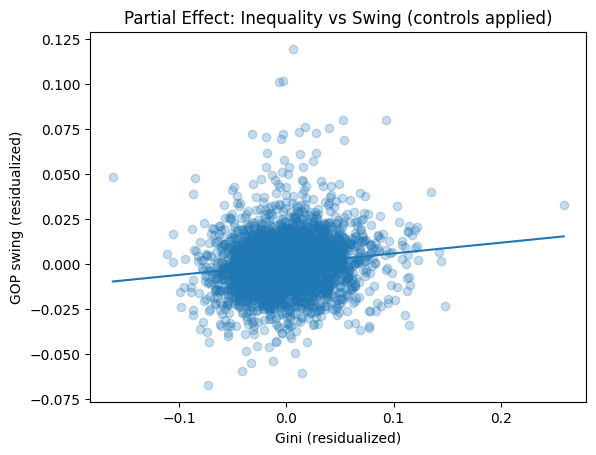

In [103]:
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt

cols = ["gop_swing", "gop_share_2020", "turnout_pct_change", "gini_index"]
d = df_merged[cols].dropna().copy()

# Residualize swing on controls
X_controls = sm.add_constant(d[["gop_share_2020", "turnout_pct_change"]])
y_resid = sm.OLS(d["gop_swing"], X_controls).fit().resid

# Residualize gini on same controls
g_resid = sm.OLS(d["gini_index"], X_controls).fit().resid

plt.figure()
plt.scatter(g_resid, y_resid, alpha=0.25)

m, b = np.polyfit(g_resid, y_resid, 1)
x = np.array([g_resid.min(), g_resid.max()])
plt.plot(x, m*x + b)

plt.xlabel("Gini (residualized)")
plt.ylabel("GOP swing (residualized)")
plt.title("Partial Effect: Inequality vs Swing (controls applied)")
plt.show()

In [115]:
import os

out_dir = "figures"
os.makedirs(out_dir, exist_ok=True)

# ... your plotting code ...
plt.tight_layout()
plt.savefig(f"{out_dir}/GOPswing_vs_gini.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{out_dir}/GOPswing_vs_gini.svg", bbox_inches="tight")  # optional (vector)
plt.show()

<Figure size 640x480 with 0 Axes>

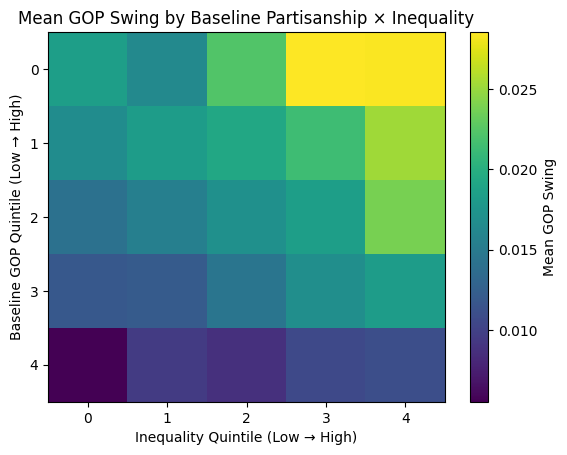

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Prepare data
d = df_merged[[
    "gop_swing",
    "gop_share_2020",
    "gini_index"
]].dropna().copy()

d["gini_index"] = pd.to_numeric(d["gini_index"], errors="coerce")

# Create quintiles
d["baseline_quintile"] = pd.qcut(d["gop_share_2020"], 5, labels=False)
d["gini_quintile"] = pd.qcut(d["gini_index"], 5, labels=False)

# Compute mean swing per cell
pivot = d.pivot_table(
    values="gop_swing",
    index="baseline_quintile",
    columns="gini_quintile",
    aggfunc="mean"
)

# Plot heatmap
plt.figure()
plt.imshow(pivot, aspect="auto")
plt.colorbar(label="Mean GOP Swing")
plt.xlabel("Inequality Quintile (Low → High)")
plt.ylabel("Baseline GOP Quintile (Low → High)")
plt.title("Mean GOP Swing by Baseline Partisanship × Inequality")
plt.xticks(range(5))
plt.yticks(range(5))
plt.show()

In [114]:
import os

out_dir = "figures"
os.makedirs(out_dir, exist_ok=True)

# ... your plotting code ...
plt.tight_layout()
plt.savefig(f"{out_dir}/swing_vs_gini.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{out_dir}/swing_vs_gini.svg", bbox_inches="tight")  # optional (vector)
plt.show()

<Figure size 640x480 with 0 Axes>